# Домашнее задание №5-6. ML-моделирование и анализ качества модели

## 1. Введение в проект

Проект посвящён мониторингу банковских риск-сигналов по новостям. Идея продукта — автоматически анализировать новостные фрагменты, в которых упоминаются банки, и определять, содержит ли фрагмент потенциально значимое риск-событие.

Исходная база датасета была подготовлена на предыдущем шаге в ДЗ №4 на основе русскоязычного новостного корпуса RuNews / `IlyaGusev/ru_news`. Из общей базы новостей были выделены материалы с банковскими упоминаниями, нормализованы названия банков и сформированы текстовые фрагменты вокруг найденных сущностей.

После подготовки фрагментов была проведена разметка для ML-задачи: каждому наблюдению присвоен бинарный target `alert_flag`, а также тип события `risk_type_4cls`. Разметка отделяет обычные банковские упоминания от риск-сигналов и группирует риск-события по основным категориям: киберриски, операционные риски и регуляторные/правовые риски.

Единица наблюдения — не вся новость целиком, а текстовый фрагмент вокруг упоминания банка. Это важно, потому что одна новость может содержать несколько банковских упоминаний, и не каждое упоминание является риск-сигналом.

Основная бизнес-логика: найти упоминания банков, выделить фрагмент вокруг упоминания, определить наличие риск-сигнала, уточнить тип риска и передать релевантные сигналы аналитику.


## 2. Данные и связь с ДЗ №4

Используется датасет из ДЗ №4:

```text
homework_04_dataset/data/dataset_for_training.csv
```

Ключевые поля: `sample_id`, `event_group_id`, `split`, `title`, `text_fragment`, `entity_norm`, `found_risk_keywords`, `source`, `published_year`, `published_month`, `alert_flag`, `risk_type_4cls`.

`event_group_id` используется для контроля утечек между train/valid/test. Это поле связывает близкие фрагменты одного инфоповода, поэтому важно, чтобы одна и та же группа событий не попадала одновременно в обучение и проверку.

`found_risk_keywords` можно использовать для анализа качества датасета, но нельзя использовать как feature. Это поле связано с правиловой логикой поиска риск-слов и может напрямую подсказать модели целевой класс, то есть создать leakage.

Дополнительно в датасете уже содержится поле `split`, сформированное на этапе ДЗ №4. Поэтому в текущей работе новое случайное разбиение не выполняется: используются заранее подготовленные выборки `train`, `valid` и `test`.

Такой подход важен для корректной валидации: разбиение было сделано с учётом `event_group_id`, чтобы один и тот же инфоповод или близкие новостные фрагменты не попадали одновременно в обучение и проверку. Это снижает риск leakage и делает оценку моделей более честной.

### Основная постановка задачи

Основная постановка в текущей работе — binary classification по `alert_flag`: модель должна определить, является ли новостной фрагмент риск-сигналом для банка.

Поле `risk_type_4cls` используется как дополнительная разметка, описывающая тип риска, но в notebook multi-class модель не включается в основной pipeline. Это сознательное ограничение: для ДЗ №5–6 фокус делается на качестве основной binary-модели, а классификация типа риска остаётся логичным следующим этапом развития продукта.


## 3. Загрузка и первичная проверка датасета


In [1]:
from pathlib import Path
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import FeatureUnion, Pipeline

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'homework_04_dataset').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'homework_04_dataset' / 'data' / 'dataset_for_training.csv'
REPORT_DIR = PROJECT_ROOT / 'homework_05_06_modeling' / 'reports'
LLM_DISTILLATION_REPORT_DIR = REPORT_DIR / 'llm_distillation'
LLM_DISTILLATION_REPORT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 160)

df = pd.read_csv(DATA_PATH)
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок')
display(df.head())
display(df.dtypes.rename('dtype').reset_index().rename(columns={'index': 'column'}))

Размер датасета: 839 строк, 12 колонок


,sample_id,event_group_id,split,text_fragment,title,entity_norm,found_risk_keywords,source,published_year,published_month,alert_flag,risk_type_4cls
0,ml_000001,eg_000001,train,"Газпромбанк и РСХБ самоустранились от проекта ""Едим дома!"" РСХБ и ГПБ заявили, что проект не соответствует их действующим кредитным программам. Росбанк (вхо...","Газпромбанк и РСХБ самоустранились от проекта ""Едим дома!""",Росбанк,NaN,buriy,2015,5,0,no_risk
1,ml_000002,eg_000002,test,"Хакеры четыре года грабили клиентов Сбербанка и ВТБ Во время задержания хакеры попытались смыть в унитаз деньги, флешки и телефоны, а также хотели уничтожит...",Хакеры четыре года грабили клиентов Сбербанка и ВТБ,ВТБ,хакеры,buriy,2015,6,1,cyber_risk
2,ml_000003,eg_000003,train,"Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций Вместе с тем страны ЕС расширили и индивидуальные ограничительные меры, добавив в санкционный ...","Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций",Газпромбанк,санкции,buriy,2014,9,0,no_risk
3,ml_000004,eg_000004,valid,"Российские банки захотели оценивать расходы клиентов по картам при выдаче кредитов Проектом заинтересовались 15 российских банков, десять из которых «занима...",Российские банки захотели оценивать расходы клиентов по картам при выдаче кредитов,ВТБ,NaN,telegram_contest,2019,11,0,no_risk
4,ml_000005,eg_000005,train,«Открытие» и «Росгосстрах» создадут крупнейшую частную финансовую группу Представители «Открытия» и «Росгосстраха» отказались от комментариев «Открытие» — о...,«Открытие» и «Росгосстрах» создадут крупнейшую частную финансовую группу,Банк Открытие,клиентская база,lenta,2016,12,0,no_risk


,column,dtype
0,sample_id,object
1,event_group_id,object
2,split,object
3,text_fragment,object
4,title,object
5,entity_norm,object
6,found_risk_keywords,object
7,source,object
8,published_year,int64
9,published_month,int64


### Вывод

Датасет загружен корректно. В нём присутствуют все ключевые поля для моделирования: текстовые признаки, готовое разбиение `split`, основной target `alert_flag` и дополнительная разметка `risk_type_4cls`.

Новое случайное разбиение в текущей работе не выполняется. Используется готовый `train/valid/test split`, сформированный на этапе ДЗ №4. Это важно для корректной валидации, так как разбиение связано с `event_group_id` и снижает риск попадания одного и того же инфоповода одновременно в обучение и проверку.

Технические поля, target-поля и `found_risk_keywords` не должны использоваться как признаки. Особенно важно исключить `found_risk_keywords`, потому что это поле связано с правиловой логикой поиска риск-слов и может создать leakage.


## 4. Проверка split и leakage-control

Проверяем, что split уже сформирован, классы представлены во всех частях, а один `event_group_id` не пересекается между train/valid/test.


In [2]:
split_summary = df.groupby('split').agg(
    rows=('sample_id', 'size'),
    positive_rate=('alert_flag', 'mean'),
    event_groups=('event_group_id', 'nunique'),
).reset_index()
display(split_summary)

target_by_split = (
    df.groupby(['split', 'alert_flag'])
    .size()
    .rename('count')
    .reset_index()
)
display(target_by_split)

split_sets = {
    split_name: set(part['event_group_id'].dropna())
    for split_name, part in df.groupby('split')
}
leakage_pairs = []
for left_name, left_values in split_sets.items():
    for right_name, right_values in split_sets.items():
        if left_name < right_name:
            overlap = left_values.intersection(right_values)
            if overlap:
                leakage_pairs.append({
                    'left_split': left_name,
                    'right_split': right_name,
                    'overlap_event_groups': len(overlap),
                })

print(f'Пересечений event_group_id между split: {len(leakage_pairs)}')
if leakage_pairs:
    display(pd.DataFrame(leakage_pairs))

,split,rows,positive_rate,event_groups
0,test,126,0.301587,110
1,train,587,0.303237,514
2,valid,126,0.301587,110


,split,alert_flag,count
0,test,0,88
1,test,1,38
2,train,0,409
3,train,1,178
4,valid,0,88
5,valid,1,38


Пересечений event_group_id между split: 0


### Вывод

Проверка split показывает, что датасет уже разделён на `train`, `valid` и `test`. Эти выборки используются без повторного random split.

`event_group_id` не должен пересекаться между train/valid/test. Это принципиально важно: если один и тот же инфоповод или близкие новостные фрагменты попадут одновременно в обучение и проверку, качество модели может быть искусственно завышено.

В текущей работе `train` используется для обучения моделей, `valid` — для выбора модели, teacher-модели и параметров distillation, а `test` — только для финальной проверки уже выбранного решения.


## 5. EDA для моделирования

На этом этапе проверяем баланс классов, распределение типов риска и длину текстовых фрагментов. EDA нужна не для выбора новой разметки, а для понимания ограничений задачи и выбора корректных метрик качества.


Несоответствий между risk_type_4cls и alert_flag: 0


,alert_flag,count
0,0,585
1,1,254


,risk_type_4cls,count
0,no_risk,585
1,cyber_risk,111
2,operational_risk,97
3,regulatory_risk,46


title_words        fragment_words       
                  mean median           mean median
alert_flag                                         
0                 8.37    8.0          60.52   58.0
1                 8.77    8.0          54.59   51.5

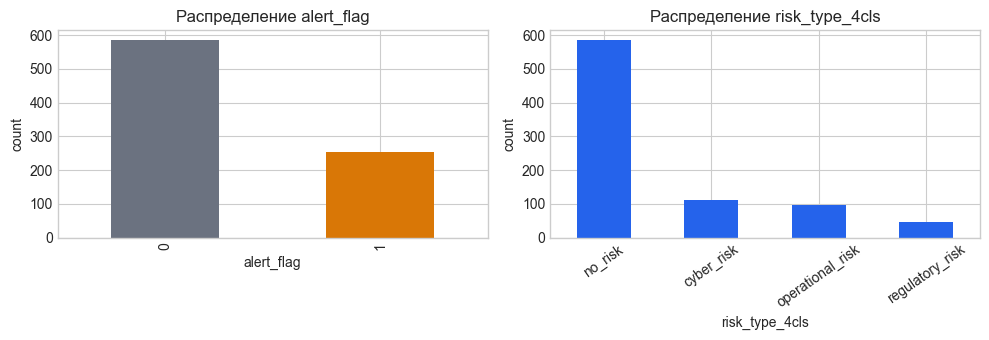

In [3]:
expected_alert = df['risk_type_4cls'].ne('no_risk').astype(int)
target_mismatches = df[df['alert_flag'].ne(expected_alert)]
print(f'Несоответствий между risk_type_4cls и alert_flag: {len(target_mismatches)}')

display(df['alert_flag'].value_counts(dropna=False).sort_index().rename_axis('alert_flag').reset_index(name='count'))
display(df['risk_type_4cls'].value_counts(dropna=False).rename_axis('risk_type_4cls').reset_index(name='count'))

df['title_words'] = df['title'].fillna('').str.split().str.len()
df['fragment_words'] = df['text_fragment'].fillna('').str.split().str.len()
display(df.groupby('alert_flag')[['title_words', 'fragment_words']].agg(['mean', 'median']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df['alert_flag'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#6b7280', '#d97706'])
axes[0].set_title('Распределение alert_flag')
axes[0].set_xlabel('alert_flag')
axes[0].set_ylabel('count')

df['risk_type_4cls'].value_counts().plot(kind='bar', ax=axes[1], color='#2563eb')
axes[1].set_title('Распределение risk_type_4cls')
axes[1].set_xlabel('risk_type_4cls')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

### Вывод

EDA для моделирования показывает, что задача имеет умеренный дисбаланс классов: отрицательный класс `alert_flag = 0` встречается чаще, чем положительный `alert_flag = 1`. Поэтому accuracy не используется как основная метрика: модель может получать приемлемую accuracy, но плохо находить риск-сигналы.

Для оценки качества используются Precision, Recall, F1, ROC-AUC и PR-AUC. Основная метрика выбора модели — F1 на valid, потому что она балансирует две важные стороны задачи: способность находить риск-сигналы и нагрузку на аналитика от ложных алертов.

Распределение классов по split не балансируется искусственно. Это делает valid/test ближе к реалистичному потоку новостей и позволяет честнее оценивать поведение модели.


## 6. Подготовка признаков и validation protocol

Для всех моделей используется только текстовое поле:

```text
title + text_fragment + entity_norm -> alert_flag
```

Технические поля, target-поля и `found_risk_keywords` не используются как признаки. Valid используется для сравнения моделей и выбора гиперпараметров. Test используется только один раз — для финальной оценки выбранного решения.


In [4]:
df['model_text'] = (
    df['title'].fillna('') + ' ' +
    df['text_fragment'].fillna('') + ' ' +
    df['entity_norm'].fillna('')
)

train_df = df[df['split'].eq('train')].copy()
valid_df = df[df['split'].eq('valid')].copy()
test_df = df[df['split'].eq('test')].copy()

X_train = train_df['model_text']
y_train = train_df['alert_flag']
X_valid = valid_df['model_text']
y_valid = valid_df['alert_flag']
X_test = test_df['model_text']
y_test = test_df['alert_flag']

binary_metrics = []
sklearn_models = {}
distilled_model_artifacts = {}


def evaluate_binary_model(model_name, y_true, y_pred, y_score):
    return pd.DataFrame([{
        'model': model_name,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }])


def show_confusion_matrix(y_true, y_pred, title, labels=[0, 1]):
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, labels=labels, ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def get_binary_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def prettify_model_name(model_name):
    mapping = {
        'TF-IDF word + LogisticRegression': 'TF-IDF word',
        'TF-IDF char + LogisticRegression': 'TF-IDF char',
        'Combined word+char TF-IDF + LogisticRegression': 'Combined TF-IDF',
        'Tuned combined word+char TF-IDF + LogisticRegression': 'Tuned combined TF-IDF',
        'LLM-distilled combined TF-IDF + LogisticRegression': 'LLM-distilled TF-IDF (teacher: GPT-4.1)',
        'LLM-distilled combined TF-IDF + LogisticRegression (teacher: gpt-4.1)': 'LLM-distilled TF-IDF (teacher: GPT-4.1)',
        'LLM-distilled combined TF-IDF + LogisticRegression (teacher: gpt-5.5 fixed v2)': 'LLM-distilled TF-IDF (teacher: GPT-5.5)',
    }
    return mapping.get(model_name, model_name)


def prettify_teacher_name(teacher_name):
    mapping = {
        'gpt-4.1': 'GPT-4.1',
        'gpt-5.5': 'GPT-5.5',
        'gpt-5.5 fixed v2': 'GPT-5.5',
    }
    return mapping.get(teacher_name, teacher_name)


def prettify_model_table(df):
    display_df = df.copy()
    if 'model' in display_df.columns:
        display_df['model'] = display_df['model'].apply(prettify_model_name)
    if 'teacher' in display_df.columns:
        display_df['teacher'] = display_df['teacher'].apply(prettify_teacher_name)
    return display_df


### Вывод

Для основной binary-задачи сформировано единое текстовое поле `model_text`, объединяющее `title`, `text_fragment` и `entity_norm`. Такой подход позволяет использовать как сам текст новости, так и контекст банковской сущности, вокруг которой был выделен фрагмент.

В качестве признаков не используются `sample_id`, `event_group_id`, `split`, `alert_flag`, `risk_type_4cls` и `found_risk_keywords`. Это снижает риск leakage и делает сравнение моделей честнее.

Validation protocol остаётся неизменным: `train` используется для обучения, `valid` — для выбора модели и гиперпараметров, `test` — только для финальной оценки.


## 7. Baseline 1: TF-IDF word

Стартовый baseline использует word-level TF-IDF и LogisticRegression. Это минимальный осмысленный уровень качества для задачи текстовой классификации.


,model,precision,recall,f1,roc_auc,pr_auc
0,TF-IDF word,0.702703,0.684211,0.693333,0.845993,0.751861


              precision    recall  f1-score   support

           0       0.87      0.88      0.87        88
           1       0.70      0.68      0.69        38

    accuracy                           0.82       126
   macro avg       0.78      0.78      0.78       126
weighted avg       0.82      0.82      0.82       126



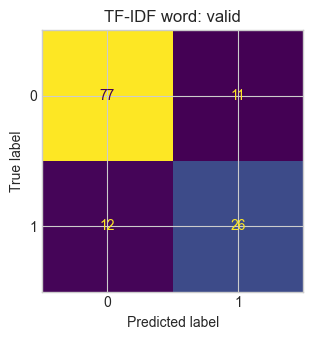

In [5]:
word_lr_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word', ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=30000
    )),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED, solver='liblinear')),
])
word_lr_model.fit(X_train, y_train)
word_valid_pred = word_lr_model.predict(X_valid)
word_valid_score = word_lr_model.predict_proba(X_valid)[:, 1]
word_metrics = evaluate_binary_model('TF-IDF word + LogisticRegression', y_valid, word_valid_pred, word_valid_score)
binary_metrics.append(word_metrics)
sklearn_models['TF-IDF word + LogisticRegression'] = word_lr_model

display(prettify_model_table(word_metrics))
print(classification_report(y_valid, word_valid_pred, zero_division=0))
show_confusion_matrix(y_valid, word_valid_pred, f'{prettify_model_name("TF-IDF word + LogisticRegression")}: valid')

### Вывод

В качестве стартового baseline используется простая модель `TF-IDF word`. Она задаёт минимальный осмысленный уровень качества для задачи классификации текстовых новостных фрагментов.

Word-level TF-IDF учитывает отдельные слова и короткие словосочетания. Такая модель хорошо подходит для текстовой классификации, когда важны конкретные термины и устойчивые фразы: “утечка данных”, “сбой сервиса”, “санкции”, “атака”, “регулятор”.

По valid-метрикам baseline уже извлекает полезный сигнал из текста: Precision = 0.703, Recall = 0.684, F1 = 0.693, ROC-AUC = 0.846, PR-AUC = 0.752. Эта модель используется как стартовая точка для дальнейших улучшений.

Confusion matrix показывает практический профиль ошибок: из 38 риск-сигналов модель находит 26 и пропускает 12, а среди отрицательных объектов даёт 11 ложных алертов. Это приемлемо для первого baseline, но Recall ещё недостаточен для задачи риск-мониторинга.


## 8. Baseline 2: TF-IDF char

Char-level TF-IDF проверяет устойчивость модели к морфологии русского языка, окончаниям и близким формулировкам.


,model,precision,recall,f1,roc_auc,pr_auc
0,TF-IDF char,0.722222,0.684211,0.702703,0.841806,0.734304


              precision    recall  f1-score   support

           0       0.87      0.89      0.88        88
           1       0.72      0.68      0.70        38

    accuracy                           0.83       126
   macro avg       0.79      0.79      0.79       126
weighted avg       0.82      0.83      0.82       126



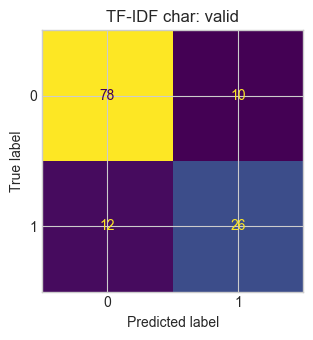

In [6]:
char_lr_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.9, max_features=50000
    )),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED, solver='liblinear')),
])
char_lr_model.fit(X_train, y_train)
char_valid_pred = char_lr_model.predict(X_valid)
char_valid_score = char_lr_model.predict_proba(X_valid)[:, 1]
char_metrics = evaluate_binary_model('TF-IDF char + LogisticRegression', y_valid, char_valid_pred, char_valid_score)
binary_metrics.append(char_metrics)
sklearn_models['TF-IDF char + LogisticRegression'] = char_lr_model

display(prettify_model_table(char_metrics))
print(classification_report(y_valid, char_valid_pred, zero_division=0))
show_confusion_matrix(y_valid, char_valid_pred, f'{prettify_model_name("TF-IDF char + LogisticRegression")}: valid')

### Вывод

Char-level TF-IDF учитывает символьные n-граммы. Для русского языка это полезно, потому что модель может улавливать морфологические варианты слов, окончания, близкие формулировки и возможные опечатки.

Этот baseline проверяет, даёт ли символьное представление текста прирост относительно word-level признаков. На valid char-модель показывает Precision = 0.722, Recall = 0.684, F1 = 0.703, ROC-AUC = 0.842, PR-AUC = 0.734. F1 и Precision немного выше, чем у word baseline, но Recall остаётся на том же уровне.

Confusion matrix подтверждает этот профиль: модель находит те же 26 из 38 риск-сигналов, но снижает число ложных алертов с 11 до 10. Следующий логичный шаг — объединить word-level и char-level TF-IDF, чтобы совместить смысловые словесные признаки и устойчивость символьных n-грамм к морфологии.


### Переход к combined TF-IDF

После проверки двух отдельных baseline-моделей логично объединить оба представления текста. Word-level TF-IDF лучше улавливает смысловые слова и устойчивые фразы, а char-level TF-IDF помогает учитывать морфологию, окончания и варианты написания.

Поэтому следующий шаг — combined-модель, которая использует оба типа признаков одновременно.


## 9. Combined word+char TF-IDF baseline

Combined-модель объединяет word-level и char-level признаки: слова и устойчивые фразы дают смысловой сигнал, а символьные n-граммы помогают с морфологией и вариативностью формулировок.


,model,precision,recall,f1,roc_auc,pr_auc
0,Combined TF-IDF,0.72973,0.710526,0.72,0.858852,0.764823


              precision    recall  f1-score   support

           0       0.88      0.89      0.88        88
           1       0.73      0.71      0.72        38

    accuracy                           0.83       126
   macro avg       0.80      0.80      0.80       126
weighted avg       0.83      0.83      0.83       126



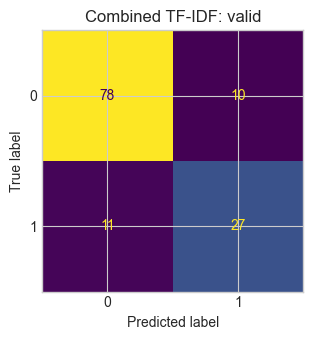

In [7]:
combined_lr_model = Pipeline([
    ('features', FeatureUnion([
        ('word_tfidf', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=30000
        )),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.9, max_features=30000
        )),
    ])),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED, solver='liblinear')),
])
combined_lr_model.fit(X_train, y_train)
combined_valid_pred = combined_lr_model.predict(X_valid)
combined_valid_score = combined_lr_model.predict_proba(X_valid)[:, 1]
combined_metrics = evaluate_binary_model('Combined word+char TF-IDF + LogisticRegression', y_valid, combined_valid_pred, combined_valid_score)
binary_metrics.append(combined_metrics)
sklearn_models['Combined word+char TF-IDF + LogisticRegression'] = combined_lr_model

display(prettify_model_table(combined_metrics))
print(classification_report(y_valid, combined_valid_pred, zero_division=0))
show_confusion_matrix(y_valid, combined_valid_pred, f'{prettify_model_name("Combined word+char TF-IDF + LogisticRegression")}: valid')

### Переход к подбору гиперпараметров

Combined TF-IDF уже является более сильной моделью по сравнению с отдельными word-level и char-level baseline. Однако качество модели зависит не только от признаков, но и от параметров классификатора.

Поэтому следующий шаг — подобрать гиперпараметры `LogisticRegression`, в первую очередь `C` и `class_weight`, чтобы получить сильную классическую модель для дальнейшего сравнения.


## 10. Подбор гиперпараметров для combined TF-IDF модели

Подбор `C` и `class_weight` через `GridSearchCV` выполняется только на train. Valid остаётся независимой частью для сравнения итоговых кандидатов.


n_jobs=-1 недоступен, fallback на n_jobs=1: [WinError 5] Отказано в доступе


Лучшие параметры: {'clf__C': 5.0, 'clf__class_weight': 'balanced'}
Лучшая CV F1: 0.6176


,model,precision,recall,f1,roc_auc,pr_auc
0,Tuned combined TF-IDF,0.771429,0.710526,0.739726,0.87201,0.790224


              precision    recall  f1-score   support

           0       0.88      0.91      0.89        88
           1       0.77      0.71      0.74        38

    accuracy                           0.85       126
   macro avg       0.83      0.81      0.82       126
weighted avg       0.85      0.85      0.85       126



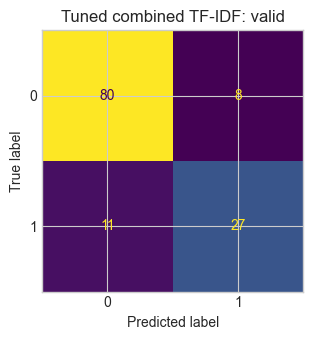

In [8]:
combined_grid_model = Pipeline([
    ('features', FeatureUnion([
        ('word_tfidf', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=30000
        )),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.9, max_features=30000
        )),
    ])),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED, solver='liblinear')),
])

param_grid = {
    'clf__C': [0.5, 1.0, 2.0, 5.0],
    'clf__class_weight': [None, 'balanced'],
}

combined_grid = GridSearchCV(
    estimator=combined_grid_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=0,
)

try:
    combined_grid.fit(X_train, y_train)
except Exception as e:
    print(f'n_jobs=-1 недоступен, fallback на n_jobs=1: {e}')
    combined_grid = GridSearchCV(
        estimator=combined_grid_model,
        param_grid=param_grid,
        scoring='f1',
        cv=3,
        n_jobs=1,
        verbose=0,
    )
    combined_grid.fit(X_train, y_train)

print('Лучшие параметры:', combined_grid.best_params_)
print(f'Лучшая CV F1: {combined_grid.best_score_:.4f}')

tuned_combined_model = combined_grid.best_estimator_
tuned_combined_valid_pred = tuned_combined_model.predict(X_valid)
tuned_combined_valid_score = tuned_combined_model.predict_proba(X_valid)[:, 1]
tuned_combined_metrics = evaluate_binary_model(
    'Tuned combined word+char TF-IDF + LogisticRegression',
    y_valid,
    tuned_combined_valid_pred,
    tuned_combined_valid_score,
)
binary_metrics.append(tuned_combined_metrics)
sklearn_models['Tuned combined word+char TF-IDF + LogisticRegression'] = tuned_combined_model

display(prettify_model_table(tuned_combined_metrics))
print(classification_report(y_valid, tuned_combined_valid_pred, zero_division=0))
show_confusion_matrix(y_valid, tuned_combined_valid_pred, f'{prettify_model_name("Tuned combined word+char TF-IDF + LogisticRegression")}: valid')

### Вывод

Combined-модель объединяет два разных представления текста: word-level и char-level TF-IDF. Word-признаки помогают учитывать смысловые слова и устойчивые фразы, а char-признаки — морфологию, окончания и близкие формулировки. Такое объединение является более содержательным усложнением по сравнению с одиночным TF-IDF, но остаётся быстрым и воспроизводимым.

На valid базовая combined-модель показывает Precision = 0.730, Recall = 0.711, F1 = 0.720, ROC-AUC = 0.859, PR-AUC = 0.765. По сравнению с одиночными TF-IDF baseline она даёт более высокий Recall и F1, то есть объединение признаков действительно добавляет полезный сигнал.

Далее был выполнен подбор гиперпараметров для combined-модели через `GridSearchCV`. Подбирались параметры `C` и `class_weight`, а оптимизация выполнялась по F1 на кросс-валидации внутри train.

`class_weight='balanced'` позволяет учесть дисбаланс классов: ошибки на редком положительном классе `alert_flag = 1` получают больший вес. Это важно для риск-мониторинга, где пропуск риск-сигнала является критичной ошибкой.

Лучшие параметры tuned-модели: `C = 5.0`, `class_weight = 'balanced'`, лучшая CV F1 = 0.618. На valid `Tuned combined TF-IDF` показывает Precision = 0.771, Recall = 0.711, F1 = 0.740, ROC-AUC = 0.872, PR-AUC = 0.790.

Итог: `Tuned combined TF-IDF` является сильной классической baseline-моделью. Она используется как основной classical ML reference для сравнения с LLM distillation.


### Переход к LLM distillation

После подбора гиперпараметров получена сильная classical ML модель — `Tuned combined TF-IDF`. Она остаётся быстрой, воспроизводимой и хорошо подходит как baseline/reference-решение.

Дальше проверяется advanced-подход: LLM distillation. В этом подходе большая языковая модель используется как teacher, а компактная TF-IDF-модель — как student. Цель эксперимента — проверить, может ли teacher-сигнал улучшить качество компактной модели без использования LLM на этапе production inference.


## 11. LLM distillation: large language model teacher -> compact student model

LLM distillation добавлена как advanced-подход по рекомендации преподавателя. В этом подходе большая языковая модель выступает teacher-моделью: она получает текстовый фрагмент и возвращает JSON с бинарной меткой `label` и уверенностью `confidence`.

Student-модель остаётся компактной и воспроизводимой: это `Combined TF-IDF`. Идея distillation состоит в том, чтобы передать student-модели часть сигнала от teacher, не используя большую LLM в production inference для каждого нового фрагмента.

Teacher confidence преобразуется в soft label: если teacher ставит `label = 1`, используется вероятность риска, близкая к `confidence`; если `label = 0`, используется `1 - confidence`. Затем student обучается на смеси исходной hard-разметки и teacher-сигнала:

```text
soft_y = (1 - alpha) * y_train + alpha * teacher_soft_proba
```

Параметр `alpha` задаёт, насколько сильно учитывать teacher-сигнал. `alpha = 0` означает обучение только на исходной разметке, а большие значения `alpha` сильнее смещают обучение в сторону soft labels от teacher.

В качестве teacher проверяются `GPT-4.1` и `GPT-5.5`. Для GPT-5.5 использовался Responses API с `reasoning={"effort": "low"}`, увеличенным `max_output_tokens` и structured JSON output. Это позволило получить валидные teacher labels для всех train-объектов.


Test в этом разделе не используется. Teacher-модели, `alpha`, `C` и финальная модель выбираются только через train/valid protocol.


In [9]:
def build_llm_teacher_prompt_short(text):
    return f"""
Ты эксперт по банковскому риск-мониторингу.

Определи, является ли новостной фрагмент риск-сигналом для банка.

Верни строго JSON без дополнительного текста:

{{
  "label": 0 или 1,
  "confidence": число от 0.0 до 1.0
}}

Правила:
- label = 1, если текст содержит риск-сигнал: кибератака, утечка данных, сбой сервиса, санкции, ограничения, регуляторный риск, операционный риск, судебный/надзорный риск.
- label = 0, если банк просто упоминается, но явного риск-сигнала нет.
- confidence отражает уверенность в метке.

Текст:
{text}
"""


def parse_llm_teacher_response_short(response_text):
    response_text = str(response_text).strip()
    start = response_text.find('{')
    end = response_text.rfind('}')
    if start >= 0 and end >= start:
        response_text = response_text[start:end + 1]

    parsed = json.loads(response_text)
    label = int(parsed['label'])
    if label not in (0, 1):
        raise ValueError(f'Некорректный label: {label}')

    confidence = float(parsed['confidence'])
    confidence = min(max(confidence, 0.0), 1.0)
    return label, confidence


def fit_logreg_with_soft_labels(X, soft_y, C=1.0, max_iter=1000, random_state=SEED):
    soft_y = np.asarray(soft_y, dtype=float)
    soft_y = np.clip(soft_y, 1e-4, 1 - 1e-4)

    X_aug = sparse.vstack([X, X])
    y_aug = np.concatenate([
        np.ones(len(soft_y), dtype=int),
        np.zeros(len(soft_y), dtype=int),
    ])
    sample_weight = np.concatenate([
        soft_y,
        1.0 - soft_y,
    ])

    model = LogisticRegression(
        C=C,
        max_iter=max_iter,
        random_state=random_state,
        solver='liblinear',
    )
    model.fit(X_aug, y_aug, sample_weight=sample_weight)
    return model


def teacher_cache_valid_count(cache_df):
    if cache_df.empty or not {'teacher_label', 'teacher_confidence'}.issubset(cache_df.columns):
        return 0
    valid_mask = cache_df['teacher_label'].isin([0, 1]) & cache_df['teacher_confidence'].notna()
    return int(valid_mask.sum())

### Teacher labels и cache

На этом этапе загружаются или формируются teacher labels от большой языковой модели. Teacher используется только для train-выборки: valid остаётся для выбора параметров, а test — для финальной проверки.

Результаты teacher-модели сохраняются в cache-файлы, чтобы не выполнять повторные API-вызовы при каждом запуске notebook. Это делает эксперимент воспроизводимым и снижает зависимость от внешнего API во время повторного выполнения работы.


In [10]:
def request_teacher_labels_gpt41(cache_path, model_name='gpt-4.1'):
    if cache_path.exists():
        print(f'Загружаем teacher cache: {cache_path}')
        return pd.read_csv(cache_path)

    legacy_cache_path = LLM_DISTILLATION_REPORT_DIR / 'llm_teacher_train_predictions.csv'
    if legacy_cache_path.exists():
        legacy_df = pd.read_csv(legacy_cache_path)
        if teacher_cache_valid_count(legacy_df) > 0:
            print(f'Используем legacy teacher cache и сохраняем как {cache_path.name}')
            legacy_df.to_csv(cache_path, index=False)
            return legacy_df

    openai_api_key = os.getenv('OPENAI_API_KEY')
    if openai_api_key is None:
        print('OPENAI_API_KEY не найден. gpt-4.1 teacher labels не запрашиваются.')
        return pd.DataFrame()

    from openai import OpenAI
    client = OpenAI(api_key=openai_api_key)
    rows = []

    for i, row in train_df.reset_index(drop=True).iterrows():
        text = str(row['model_text'])[:2500]
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[{'role': 'user', 'content': build_llm_teacher_prompt_short(text)}],
                response_format={'type': 'json_object'},
            )
            answer = response.choices[0].message.content
            teacher_label, teacher_confidence = parse_llm_teacher_response_short(answer)
            teacher_reason = 'ok'
        except Exception as e:
            print(f'gpt-4.1 teacher failed for sample_id={row["sample_id"]}: {e}')
            teacher_label, teacher_confidence, teacher_reason = -1, np.nan, str(e)

        rows.append({
            'sample_id': row['sample_id'],
            'text_fragment': row['text_fragment'],
            'title': row['title'],
            'entity_norm': row['entity_norm'],
            'alert_flag': row['alert_flag'],
            'teacher_model': model_name,
            'teacher_label': teacher_label,
            'teacher_confidence': teacher_confidence,
            'teacher_reason': teacher_reason,
        })

        if (i + 1) % 25 == 0:
            print(f'gpt-4.1 teacher train labels: {i + 1}/{len(train_df)}')
        time.sleep(0.2)

    teacher_df = pd.DataFrame(rows)
    teacher_df.to_csv(cache_path, index=False)
    print(f'gpt-4.1 teacher cache saved: {cache_path}')
    return teacher_df


def request_teacher_labels_gpt55_fixed_v2(cache_path, model_name='gpt-5.5'):
    if cache_path.exists():
        print(f'Загружаем teacher cache: {cache_path}')
        return pd.read_csv(cache_path)

    openai_api_key = os.getenv('OPENAI_API_KEY')
    if openai_api_key is None:
        print('OPENAI_API_KEY не найден. GPT-5.5 teacher labels не запрашиваются.')
        return pd.DataFrame()

    from openai import OpenAI
    client = OpenAI(api_key=openai_api_key)
    rows = []

    for i, row in train_df.reset_index(drop=True).iterrows():
        text = str(row['model_text'])[:2500]
        try:
            response = client.responses.create(
                model=model_name,
                input=build_llm_teacher_prompt_short(text),
                reasoning={'effort': 'low'},
                max_output_tokens=2000,
                text={
                    'format': {
                        'type': 'json_schema',
                        'name': 'bank_risk_teacher_label',
                        'strict': True,
                        'schema': {
                            'type': 'object',
                            'properties': {
                                'label': {'type': 'integer', 'enum': [0, 1]},
                                'confidence': {'type': 'number', 'minimum': 0.0, 'maximum': 1.0},
                            },
                            'required': ['label', 'confidence'],
                            'additionalProperties': False,
                        },
                    }
                },
            )
            answer = response.output_text
            teacher_label, teacher_confidence = parse_llm_teacher_response_short(answer)
            teacher_reason = 'structured_json_low_reasoning'
        except Exception as e:
            print(f'GPT-5.5 teacher failed for sample_id={row["sample_id"]}: {e}')
            teacher_label, teacher_confidence, teacher_reason = -1, np.nan, str(e)

        rows.append({
            'sample_id': row['sample_id'],
            'text_fragment': row['text_fragment'],
            'title': row['title'],
            'entity_norm': row['entity_norm'],
            'alert_flag': row['alert_flag'],
            'teacher_model': model_name,
            'teacher_label': teacher_label,
            'teacher_confidence': teacher_confidence,
            'teacher_reason': teacher_reason,
        })

        if (i + 1) % 25 == 0:
            print(f'GPT-5.5 teacher train labels: {i + 1}/{len(train_df)}')
        time.sleep(0.2)

    teacher_df = pd.DataFrame(rows)
    teacher_df.to_csv(cache_path, index=False)
    print(f'GPT-5.5 teacher cache saved: {cache_path}')
    return teacher_df


### Преобразование teacher-сигнала в soft labels

Teacher-модель возвращает бинарную метку и confidence. Эти значения преобразуются в soft label — вероятность принадлежности объекта к классу `alert_flag = 1`.

Далее student-модель обучается не только на исходной hard-разметке, но и на teacher-сигнале. Вес teacher-сигнала регулируется параметром `alpha`: чем выше `alpha`, тем сильнее влияние LLM-teacher на обучение student-модели.


### Выбор параметров distillation

Для distillation подбираются параметры `alpha` и `C`. Оценка выполняется на valid по F1, потому что именно эта метрика выбрана основной для сравнения моделей.

Test-выборка на этом этапе не используется. Это важно, чтобы не подбирать teacher-модель или параметры distillation задним числом под test.


In [11]:
def run_distillation_for_teacher(teacher_df, teacher_display_name):
    model_display_name = f'LLM-distilled combined TF-IDF + LogisticRegression (teacher: {teacher_display_name})'

    if teacher_df.empty or not {'sample_id', 'teacher_label', 'teacher_confidence'}.issubset(teacher_df.columns):
        print(f'{prettify_teacher_name(teacher_display_name)}: teacher cache пустой или неполный, distillation пропущена.')
        return None

    teacher_signal_df = train_df[['sample_id', 'model_text', 'alert_flag']].merge(
        teacher_df[['sample_id', 'teacher_label', 'teacher_confidence']],
        on='sample_id',
        how='left',
    )
    valid_teacher_mask = teacher_signal_df['teacher_label'].isin([0, 1]) & teacher_signal_df['teacher_confidence'].notna()
    valid_count = int(valid_teacher_mask.sum())
    print(f'{prettify_teacher_name(teacher_display_name)}: valid teacher labels {valid_count}/{len(train_df)}')

    if valid_count == 0:
        print(f'{prettify_teacher_name(teacher_display_name)}: нет валидных teacher labels, distillation пропущена.')
        return None

    distill_train_texts = teacher_signal_df.loc[valid_teacher_mask, 'model_text']
    distill_y_train = teacher_signal_df.loc[valid_teacher_mask, 'alert_flag'].astype(float).to_numpy()
    teacher_label = teacher_signal_df.loc[valid_teacher_mask, 'teacher_label'].astype(int).to_numpy()
    teacher_confidence = teacher_signal_df.loc[valid_teacher_mask, 'teacher_confidence'].astype(float).to_numpy()

    teacher_soft_proba = np.where(
        teacher_label == 1,
        teacher_confidence,
        1.0 - teacher_confidence,
    )
    teacher_soft_proba = np.clip(teacher_soft_proba, 1e-4, 1 - 1e-4)

    vectorizer = FeatureUnion([
        ('word_tfidf', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=30000
        )),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.9, max_features=30000
        )),
    ])
    X_train_distill = vectorizer.fit_transform(distill_train_texts)
    X_valid_distill = vectorizer.transform(X_valid)

    alpha_values = [0.2, 0.3, 0.5]
    C_values = [0.5, 1.0, 2.0, 5.0]
    rows = []

    for alpha in alpha_values:
        soft_y = (1 - alpha) * distill_y_train + alpha * teacher_soft_proba
        for C in C_values:
            student_model = fit_logreg_with_soft_labels(
                X_train_distill,
                soft_y,
                C=C,
                max_iter=1000,
                random_state=SEED,
            )
            valid_proba = student_model.predict_proba(X_valid_distill)[:, 1]
            valid_pred = (valid_proba >= 0.5).astype(int)
            rows.append({
                'teacher': teacher_display_name,
                'alpha': alpha,
                'C': C,
                'precision': precision_score(y_valid, valid_pred, zero_division=0),
                'recall': recall_score(y_valid, valid_pred, zero_division=0),
                'f1': f1_score(y_valid, valid_pred, zero_division=0),
                'roc_auc': roc_auc_score(y_valid, valid_proba),
                'pr_auc': average_precision_score(y_valid, valid_proba),
            })

    results_df_teacher = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
    best_params = results_df_teacher.iloc[0][['alpha', 'C']].to_dict()
    best_alpha = float(best_params['alpha'])
    best_C = float(best_params['C'])
    best_soft_y = (1 - best_alpha) * distill_y_train + best_alpha * teacher_soft_proba
    best_model = fit_logreg_with_soft_labels(
        X_train_distill,
        best_soft_y,
        C=best_C,
        max_iter=1000,
        random_state=SEED,
    )
    best_valid_proba = best_model.predict_proba(X_valid_distill)[:, 1]
    best_valid_pred = (best_valid_proba >= 0.5).astype(int)
    best_metrics = evaluate_binary_model(model_display_name, y_valid, best_valid_pred, best_valid_proba)

    binary_metrics.append(best_metrics)
    distilled_model_artifacts[model_display_name] = {
        'model': best_model,
        'vectorizer': vectorizer,
    }

    display(prettify_model_table(results_df_teacher))
    display(prettify_model_table(best_metrics))
    print(classification_report(y_valid, best_valid_pred, zero_division=0))
    show_confusion_matrix(y_valid, best_valid_pred, f'{prettify_model_name(model_display_name)}: valid')

    return {
        'teacher': teacher_display_name,
        'model_name': model_display_name,
        'results_df': results_df_teacher,
        'best_params': best_params,
        'best_model': best_model,
        'vectorizer': vectorizer,
        'best_valid_proba': best_valid_proba,
        'best_valid_pred': best_valid_pred,
        'best_metrics': best_metrics,
    }


## 12. Сравнение LLM teacher-моделей: GPT-4.1 vs GPT-5.5

Teacher labels берутся только для train и кэшируются. Если cache уже существует, API повторно не вызывается. Valid используется для выбора `alpha` и `C`, а test в этом процессе не участвует.

Для каждого teacher строится одинаковая student-модель `Combined TF-IDF`. Это позволяет сравнивать именно качество teacher-сигнала, а не разные архитектуры student-моделей.


### Сравнение teacher-моделей

После обучения student-моделей можно сравнить, какой teacher-сигнал оказался полезнее на valid. В текущем эксперименте сравниваются teacher-модели `GPT-4.1` и `GPT-5.5`.

Важно, что сравнение выполняется по valid-метрикам. Более мощная teacher-модель не обязана автоматически давать лучший результат: качество зависит от prompt-инструкции, confidence-калибровки, размера датасета и профиля ошибок teacher.


Загружаем teacher cache: D:\6 - Обучение\ML Engineering\bank-news-risk-monitoring\homework_05_06_modeling\reports\llm_distillation\llm_teacher_train_predictions_gpt-4_1.csv
Загружаем teacher cache: D:\6 - Обучение\ML Engineering\bank-news-risk-monitoring\homework_05_06_modeling\reports\llm_distillation\llm_teacher_train_predictions_gpt-5_5_fixed_v2.csv


,teacher,cache_path,rows,valid_teacher_labels
0,GPT-4.1,D:\6 - Обучение\ML Engineering\bank-news-risk-monitoring\homework_05_06_modeling\reports\llm_distillation\llm_teacher_train_predictions_gpt-4_1.csv,587,587
1,GPT-5.5,D:\6 - Обучение\ML Engineering\bank-news-risk-monitoring\homework_05_06_modeling\reports\llm_distillation\llm_teacher_train_predictions_gpt-5_5_fixed_v2.csv,587,587


GPT-4.1: valid teacher labels 587/587


,teacher,alpha,C,precision,recall,f1,roc_auc,pr_auc
0,GPT-4.1,0.3,2.0,0.783784,0.763158,0.773333,0.900419,0.811274
1,GPT-4.1,0.3,5.0,0.714286,0.789474,0.750000,0.904904,0.825375
2,GPT-4.1,0.5,5.0,0.660000,0.868421,0.750000,0.899222,0.817722
3,GPT-4.1,0.5,2.0,0.666667,0.842105,0.744186,0.903708,0.822758
4,GPT-4.1,0.5,0.5,0.697674,0.789474,0.740741,0.902811,0.810760
5,GPT-4.1,0.2,5.0,0.771429,0.710526,0.739726,0.899522,0.815103
6,GPT-4.1,0.5,1.0,0.673913,0.815789,0.738095,0.904306,0.823512
7,GPT-4.1,0.2,1.0,0.827586,0.631579,0.716418,0.886962,0.791124
8,GPT-4.1,0.3,0.5,0.821429,0.605263,0.696970,0.892045,0.798067
9,GPT-4.1,0.2,2.0,0.750000,0.631579,0.685714,0.894438,0.798975


,model,precision,recall,f1,roc_auc,pr_auc
0,LLM-distilled TF-IDF (teacher: GPT-4.1),0.783784,0.763158,0.773333,0.900419,0.811274


              precision    recall  f1-score   support

           0       0.90      0.91      0.90        88
           1       0.78      0.76      0.77        38

    accuracy                           0.87       126
   macro avg       0.84      0.84      0.84       126
weighted avg       0.86      0.87      0.86       126



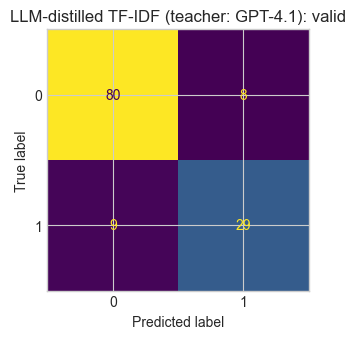

GPT-5.5: valid teacher labels 587/587


,teacher,alpha,C,precision,recall,f1,roc_auc,pr_auc
0,GPT-5.5,0.3,5.0,0.688889,0.815789,0.746988,0.894737,0.804718
1,GPT-5.5,0.2,2.0,0.771429,0.710526,0.739726,0.884868,0.792839
2,GPT-5.5,0.2,1.0,0.806452,0.657895,0.724638,0.876495,0.779727
3,GPT-5.5,0.3,1.0,0.729730,0.710526,0.720000,0.886364,0.795983
4,GPT-5.5,0.3,2.0,0.674419,0.763158,0.716049,0.891148,0.797701
5,GPT-5.5,0.3,0.5,0.742857,0.684211,0.712329,0.878289,0.776588
6,GPT-5.5,0.2,5.0,0.710526,0.710526,0.710526,0.891148,0.799104
7,GPT-5.5,0.5,0.5,0.578947,0.868421,0.694737,0.891148,0.795327
8,GPT-5.5,0.5,1.0,0.568966,0.868421,0.687500,0.892943,0.803526
9,GPT-5.5,0.5,2.0,0.568966,0.868421,0.687500,0.894737,0.805938


,model,precision,recall,f1,roc_auc,pr_auc
0,LLM-distilled TF-IDF (teacher: GPT-5.5),0.688889,0.815789,0.746988,0.894737,0.804718


              precision    recall  f1-score   support

           0       0.91      0.84      0.88        88
           1       0.69      0.82      0.75        38

    accuracy                           0.83       126
   macro avg       0.80      0.83      0.81       126
weighted avg       0.85      0.83      0.84       126



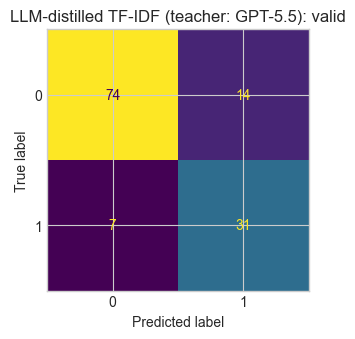

,model,precision,recall,f1,roc_auc,pr_auc
0,LLM-distilled TF-IDF (teacher: GPT-4.1),0.783784,0.763158,0.773333,0.900419,0.811274
1,LLM-distilled TF-IDF (teacher: GPT-5.5),0.688889,0.815789,0.746988,0.894737,0.804718


In [12]:
GPT41_CACHE_PATH = LLM_DISTILLATION_REPORT_DIR / 'llm_teacher_train_predictions_gpt-4_1.csv'
GPT55_FIXED_V2_CACHE_PATH = LLM_DISTILLATION_REPORT_DIR / 'llm_teacher_train_predictions_gpt-5_5_fixed_v2.csv'

teacher_cache_gpt41 = request_teacher_labels_gpt41(GPT41_CACHE_PATH)
teacher_cache_gpt55_fixed_v2 = request_teacher_labels_gpt55_fixed_v2(GPT55_FIXED_V2_CACHE_PATH)

teacher_cache_summary = pd.DataFrame([
    {
        'teacher': 'gpt-4.1',
        'cache_path': str(GPT41_CACHE_PATH),
        'rows': len(teacher_cache_gpt41),
        'valid_teacher_labels': teacher_cache_valid_count(teacher_cache_gpt41),
    },
    {
        'teacher': 'gpt-5.5 fixed v2',
        'cache_path': str(GPT55_FIXED_V2_CACHE_PATH),
        'rows': len(teacher_cache_gpt55_fixed_v2),
        'valid_teacher_labels': teacher_cache_valid_count(teacher_cache_gpt55_fixed_v2),
    },
])
display(prettify_model_table(teacher_cache_summary))

llm_distillation_runs = []
for teacher_df, teacher_name in [
    (teacher_cache_gpt41, 'gpt-4.1'),
    (teacher_cache_gpt55_fixed_v2, 'gpt-5.5 fixed v2'),
]:
    run_result = run_distillation_for_teacher(teacher_df, teacher_name)
    if run_result is not None:
        llm_distillation_runs.append(run_result)

if llm_distillation_runs:
    llm_teacher_comparison_df = pd.concat(
        [run['best_metrics'] for run in llm_distillation_runs],
        ignore_index=True,
    ).sort_values('f1', ascending=False)
else:
    llm_teacher_comparison_df = pd.DataFrame()

display(prettify_model_table(llm_teacher_comparison_df))


### Вывод

LLM distillation добавлена как advanced-подход по рекомендации преподавателя. В этом подходе большая языковая модель используется как teacher: она возвращает не только бинарную метку риска, но и confidence. Этот confidence преобразуется в soft label и используется для обучения компактной student-модели.

Student-моделью выбрана `Combined TF-IDF`: она быстрее, дешевле и проще для воспроизводимого применения, чем большая языковая модель, но может получить дополнительный сигнал от teacher.

На valid лучшая distillation-модель с teacher `GPT-4.1` показывает Precision = 0.784, Recall = 0.763, F1 = 0.773, ROC-AUC = 0.900, PR-AUC = 0.811. Это лучший valid F1 среди зрелых кандидатов, поэтому именно она выбирается финальной моделью по valid.

Для `GPT-5.5` лучший valid-результат имеет Precision = 0.689, Recall = 0.816, F1 = 0.747, ROC-AUC = 0.895, PR-AUC = 0.805. Эта модель выглядит более recall-oriented, но по valid F1 уступает `GPT-4.1`.


Teacher-модели сравниваются только на valid. Test не используется для выбора teacher, `alpha`, `C` или финальной модели.


## 13. Выбор финальной модели по valid

Сравниваем только зрелые кандидаты clean notebook. Основная метрика выбора — valid F1.

В этот список входят сильная tuned TF-IDF baseline-модель и LLM-distilled student-модели. Test-выборка на этом этапе не используется: она остаётся независимой финальной проверкой уже выбранного решения.


,model,precision,recall,f1,roc_auc,pr_auc
0,LLM-distilled TF-IDF (teacher: GPT-4.1),0.783784,0.763158,0.773333,0.900419,0.811274
1,LLM-distilled TF-IDF (teacher: GPT-5.5),0.688889,0.815789,0.746988,0.894737,0.804718
2,Tuned combined TF-IDF,0.771429,0.710526,0.739726,0.872010,0.790224
3,Combined TF-IDF,0.729730,0.710526,0.720000,0.858852,0.764823
4,TF-IDF char,0.722222,0.684211,0.702703,0.841806,0.734304
5,TF-IDF word,0.702703,0.684211,0.693333,0.845993,0.751861


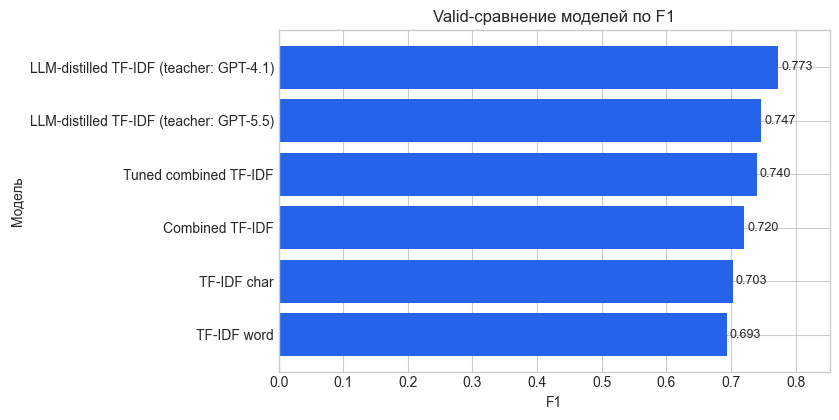

Финальная модель по valid F1: LLM-distilled TF-IDF (teacher: GPT-4.1)


In [13]:
valid_results_df = pd.concat(binary_metrics, ignore_index=True).sort_values('f1', ascending=False).reset_index(drop=True)
valid_summary_df = valid_results_df.copy()
display(prettify_model_table(valid_summary_df))

valid_plot_df = valid_summary_df.copy()
valid_plot_df['model_display'] = valid_plot_df['model'].apply(prettify_model_name)
valid_plot_df = valid_plot_df.sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 0.5 * len(valid_plot_df) + 1.3))
ax.barh(valid_plot_df['model_display'], valid_plot_df['f1'], color='#2563eb')

for value, model_name in zip(valid_plot_df['f1'], valid_plot_df['model_display']):
    ax.text(value + 0.005, model_name, f'{value:.3f}', va='center', fontsize=9)

ax.set_title('Valid-сравнение моделей по F1')
ax.set_xlabel('F1')
ax.set_ylabel('Модель')
ax.set_xlim(0, min(1.0, valid_plot_df['f1'].max() + 0.08))
plt.tight_layout()
plt.show()

final_model_name = valid_results_df.iloc[0]['model']
print(f'Финальная модель по valid F1: {prettify_model_name(final_model_name)}')


### Вывод

На valid лучшее значение F1 показала модель `LLM-distilled TF-IDF (teacher: GPT-4.1)` — F1 = `0.773`. Это выше результата сильной классической модели `Tuned combined TF-IDF`, у которой F1 = `0.740`.

Модель `LLM-distilled TF-IDF (teacher: GPT-5.5)` также показала качество выше базовых TF-IDF-моделей, но на valid уступила варианту с teacher `GPT-4.1`. Это показывает, что в текущем эксперименте более мощная LLM-teacher не дала автоматического прироста по основной метрике выбора.

Вероятно, результат зависит не только от мощности teacher-модели, но и от размера датасета, качества разметки, prompt-инструкции, confidence-калибровки и того, какой профиль ошибок формирует teacher. В частности, GPT-5.5 может давать более recall-oriented сигнал, но при этом снижать Precision.

Выбор модели выполняется только на valid. Test-выборка на этом этапе не используется и остаётся независимой финальной проверкой уже выбранного решения.

Итог: LLM distillation дала прирост относительно tuned TF-IDF на valid, а лучшим teacher-вариантом на этапе выбора оказался `GPT-4.1`.


## 14. Финальная оценка на test

На test не переизбираем модель. Показываем сильную классическую baseline-модель, финальную модель, выбранную по valid F1, и reference-only сравнение с `GPT-5.5`, если соответствующий distilled artifact доступен. Test не использовался для выбора модели, teacher, `alpha`, `C` или threshold.


,model,precision,recall,f1,roc_auc,pr_auc
0,Tuned combined TF-IDF,0.861111,0.815789,0.837838,0.966507,0.940388


Classification report: Tuned combined TF-IDF
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        88
           1       0.86      0.82      0.84        38

    accuracy                           0.90       126
   macro avg       0.89      0.88      0.89       126
weighted avg       0.90      0.90      0.90       126



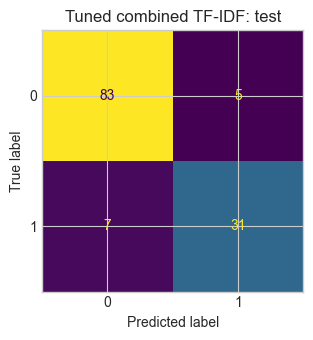

,model,precision,recall,f1,roc_auc,pr_auc
0,LLM-distilled TF-IDF (teacher: GPT-4.1),0.90625,0.763158,0.828571,0.966507,0.933834


Classification report: LLM-distilled TF-IDF (teacher: GPT-4.1)
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        88
           1       0.91      0.76      0.83        38

    accuracy                           0.90       126
   macro avg       0.91      0.86      0.88       126
weighted avg       0.90      0.90      0.90       126



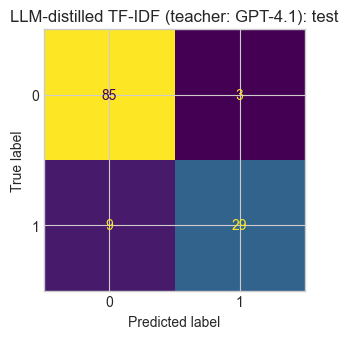

,model,precision,recall,f1,roc_auc,pr_auc
0,LLM-distilled TF-IDF (teacher: GPT-5.5),0.795455,0.921053,0.853659,0.959031,0.924877


Classification report: LLM-distilled TF-IDF (teacher: GPT-5.5)
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        88
           1       0.80      0.92      0.85        38

    accuracy                           0.90       126
   macro avg       0.88      0.91      0.89       126
weighted avg       0.91      0.90      0.91       126



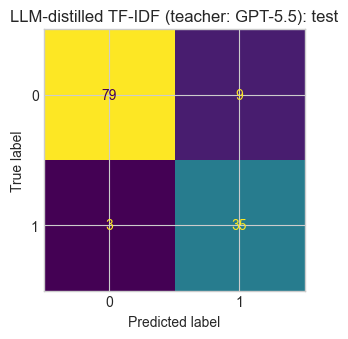

,model,precision,recall,f1,roc_auc,pr_auc
2,LLM-distilled TF-IDF (teacher: GPT-5.5),0.795455,0.921053,0.853659,0.959031,0.924877
0,Tuned combined TF-IDF,0.861111,0.815789,0.837838,0.966507,0.940388
1,LLM-distilled TF-IDF (teacher: GPT-4.1),0.906250,0.763158,0.828571,0.966507,0.933834


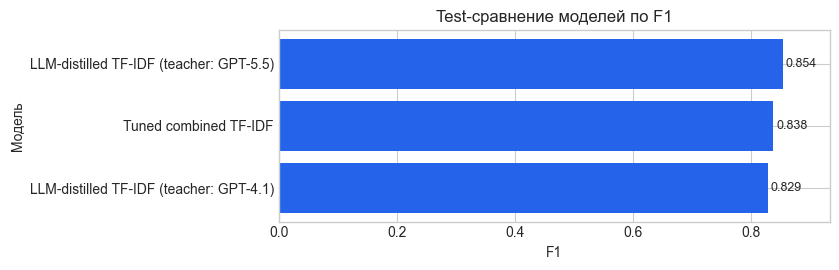

In [14]:
def evaluate_on_test_by_name(model_name):
    if model_name in sklearn_models:
        test_score = get_binary_scores(sklearn_models[model_name], X_test)

    elif model_name in distilled_model_artifacts:
        artifact = distilled_model_artifacts[model_name]
        X_test_distilled = artifact["vectorizer"].transform(X_test)
        test_score = artifact["model"].predict_proba(X_test_distilled)[:, 1]

    else:
        raise ValueError(f"Нет test evaluator для модели: {model_name}")

    test_pred = (test_score >= 0.5).astype(int)
    metrics = evaluate_binary_model(model_name, y_test, test_pred, test_score)
    return metrics, test_pred, test_score


strong_baseline_name = "Tuned combined word+char TF-IDF + LogisticRegression"

gpt55_reference_name = (
    "LLM-distilled combined TF-IDF + LogisticRegression "
    "(teacher: gpt-5.5 fixed v2)"
)

test_model_names = [
    strong_baseline_name,
    final_model_name,
    gpt55_reference_name,
]

# Убираем дубли, если final_model_name совпадает с baseline или GPT-5.5 reference.
test_model_names = list(dict.fromkeys(test_model_names))

test_metrics_list_extended = []
test_predictions_extended = {}
test_scores_extended = {}

for model_name in test_model_names:
    try:
        metrics, pred, score = evaluate_on_test_by_name(model_name)

        test_metrics_list_extended.append(metrics)
        test_predictions_extended[model_name] = pred
        test_scores_extended[model_name] = score

        display(prettify_model_table(metrics))
        print(f"Classification report: {prettify_model_name(model_name)}")
        print(classification_report(y_test, pred, zero_division=0))

        show_confusion_matrix(
            y_test,
            pred,
            f"{prettify_model_name(model_name)}: test",
            labels=[0, 1],
        )

    except Exception as e:
        print(f"[SKIP] Не удалось оценить на test модель: {prettify_model_name(model_name)}")
        print(e)


test_summary_df_extended = (
    pd.concat(test_metrics_list_extended, ignore_index=True)
    .drop_duplicates("model")
    .sort_values("f1", ascending=False)
)

display(prettify_model_table(test_summary_df_extended))

test_plot_df = test_summary_df_extended.copy()
test_plot_df["model_display"] = test_plot_df["model"].apply(prettify_model_name)
test_plot_df = test_plot_df.sort_values("f1", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 0.5 * len(test_plot_df) + 1.3))
ax.barh(test_plot_df["model_display"], test_plot_df["f1"], color="#2563eb")

for value, model_name in zip(test_plot_df["f1"], test_plot_df["model_display"]):
    ax.text(value + 0.005, model_name, f"{value:.3f}", va="center", fontsize=9)

ax.set_title("Test-сравнение моделей по F1")
ax.set_xlabel("F1")
ax.set_ylabel("Модель")
ax.set_xlim(0, min(1.0, test_plot_df["f1"].max() + 0.08))
plt.tight_layout()
plt.show()


### Вывод по test-графику

На test лучшее значение F1 показала LLM-distilled модель с teacher `GPT-5.5`. При этом она также дала самый высокий Recall, то есть лучше находила риск-сигналы. Это важно для задачи риск-мониторинга, где пропуск риска является критичной ошибкой.

`Tuned combined TF-IDF` остаётся сильной классической моделью: она показывает близкий F1 и более высокий Precision/PR-AUC. Это означает, что классическая модель делает меньше ложных алертов и остаётся устойчивым reference-решением.

Важно: test используется только для финальной проверки и диагностического сравнения. Финальный выбор модели не должен подгоняться задним числом под test. Результат GPT-5.5 показывает перспективность LLM distillation, но для строгого подтверждения преимущества нужно больше данных или дополнительный holdout.


### Вывод по test

Финальная модель выбиралась по valid F1. Test-выборка не использовалась для выбора модели, teacher-модели, параметров distillation или threshold.

На test дополнительно показано сравнение с `GPT-5.5` для  справки. Эта модель показала лучший test F1 и самый высокий Recall среди сравниваемых моделей. Это означает, что distillation от `GPT-5.5` даёт наиболее recall-oriented профиль: модель лучше находит риск-сигналы, но при этом имеет более низкий Precision, то есть создаёт больше ложных алертов.

`Tuned combined TF-IDF` остаётся сильной классической baseline-моделью: она показывает высокий F1, более высокий Precision и сильный PR-AUC. Это подтверждает, что классический TF-IDF-подход остаётся конкурентным даже на фоне LLM distillation.

`GPT-4.1 distillation`, выбранная по valid F1 как финальная модель, на test показывает самый высокий Precision среди трёх моделей, но более низкий Recall. Такой профиль означает более точные алерты при большем числе пропущенных риск-сигналов.

Важно: результат `GPT-5.5` на test не используется для переизбрания модели задним числом. Он интерпретируется как диагностическое подтверждение потенциала LLM distillation. Для строгого выбора модели нужно опираться на valid, а test использовать как независимую финальную проверку.


## 15. Итоговые выводы

В работе построен полный путь от простых baseline-моделей к advanced-подходу через LLM distillation.

Сначала были проверены две простые текстовые модели: `TF-IDF word` и `TF-IDF char`. Они показали, что в данных есть устойчивый текстовый сигнал, позволяющий отделять обычные банковские упоминания от риск-сигналов.

Затем была построена combined-модель, объединяющая word-level и char-level TF-IDF признаки. Подбор гиперпараметров через `GridSearchCV` позволил получить сильную классическую baseline-модель `Tuned combined TF-IDF`.

После этого был проверен advanced-подход — LLM distillation. Большая языковая модель выступала teacher-моделью, а компактная TF-IDF + LogisticRegression модель — student-моделью. Были сравнены teacher-модели `GPT-4.1` и `GPT-5.5`.

Результаты показывают, что LLM distillation действительно может добавлять полезный сигнал. Особенно интересен вариант с `GPT-5.5`: на test он показал лучший F1 и самый высокий Recall, что важно для задачи риск-мониторинга, где пропуск риск-сигнала является критичной ошибкой.

При этом результаты valid/test различаются, поэтому делать чрезмерно сильный вывод о безусловном превосходстве LLM distillation нельзя. На небольшом датасете метрики чувствительны к составу split, а несколько объектов могут заметно изменить Precision, Recall и F1.

Итог: `Tuned combined TF-IDF` является сильным и устойчивым classical ML решением, а LLM distillation с `GPT-5.5` — наиболее перспективным advanced-направлением для дальнейшей проверки. Для следующей версии проекта стоит увеличить датасет, перепроверить пограничные false positives/false negatives и подтвердить качество на новом holdout или через cross-validation.


In [15]:
print("Best valid model:")
display(prettify_model_table(valid_summary_df.sort_values("f1", ascending=False).head(1)))

print("Test comparison:")
display(prettify_model_table(test_summary_df_extended.sort_values("f1", ascending=False)))


Best valid model:


,model,precision,recall,f1,roc_auc,pr_auc
0,LLM-distilled TF-IDF (teacher: GPT-4.1),0.783784,0.763158,0.773333,0.900419,0.811274


Test comparison:


,model,precision,recall,f1,roc_auc,pr_auc
2,LLM-distilled TF-IDF (teacher: GPT-5.5),0.795455,0.921053,0.853659,0.959031,0.924877
0,Tuned combined TF-IDF,0.861111,0.815789,0.837838,0.966507,0.940388
1,LLM-distilled TF-IDF (teacher: GPT-4.1),0.906250,0.763158,0.828571,0.966507,0.933834
